 ## 9-Qubit Shor Code


Installation & Imports

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.quantum_info import Statevector, state_fidelity, DensityMatrix
from qiskit.visualization import plot_histogram

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

simulator = AerSimulator(method='statevector')

print('✅ All imports successful')
print(f'   Simulator: {simulator.name}')

✅ All imports successful
   Simulator: aer_simulator_statevector


 Encoding Circuit — |0⟩_L and |1⟩_L


Shor Code Encoding Circuit for |0⟩_L :


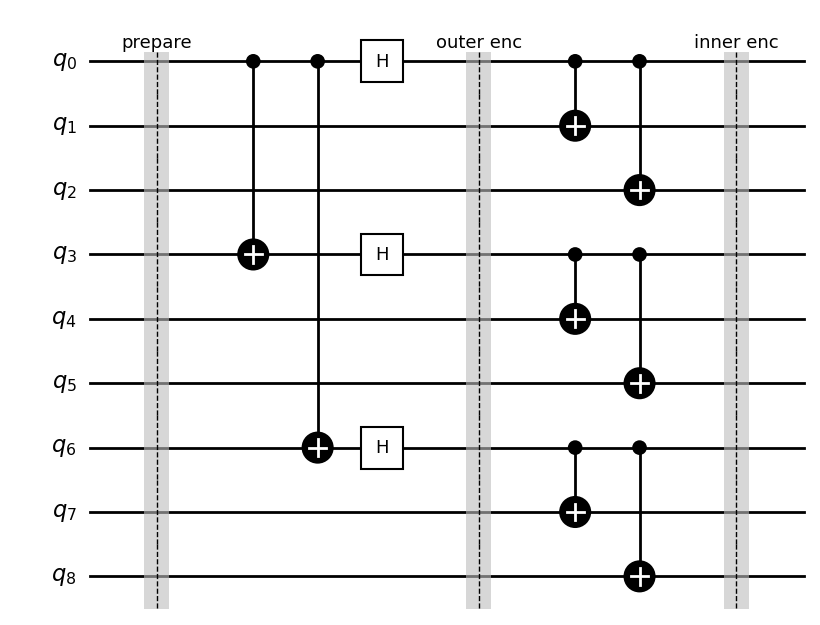


Shor Code Encoding Circuit for |1⟩_L :


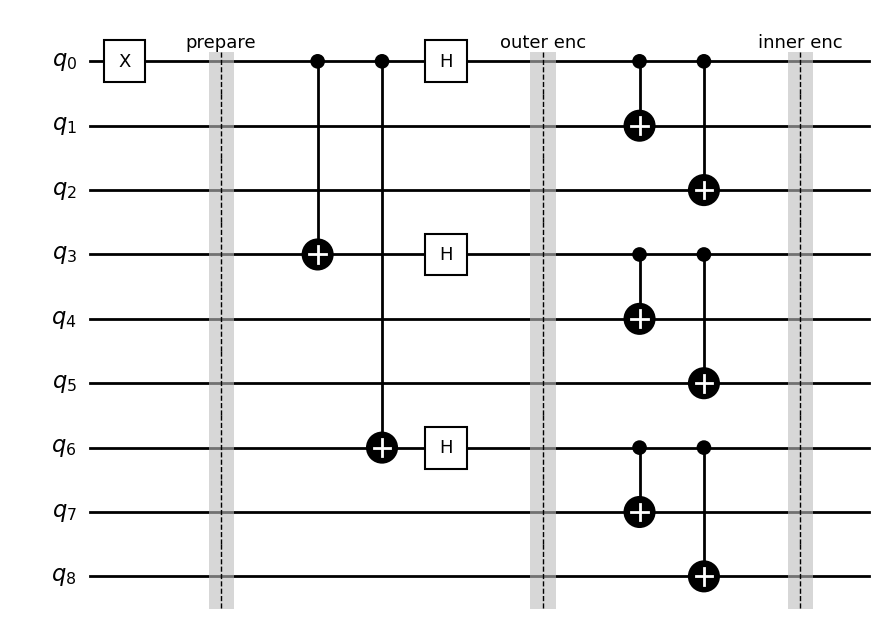


── Statevector Verification ─────────────────────────────────────────

  |0⟩_L — 8 non-zero basis states:
    |000000000⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |000000111⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |000111000⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |000111111⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |111000000⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |111000111⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |111111000⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |111111111⟩  prob = 0.1250  (amplitude ≈ 0.3536)
  Total probability = 1.000000  (should be 1.0)

  |1⟩_L — 8 non-zero basis states:
    |000000000⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |000000111⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |000111000⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |000111111⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |111000000⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |111000111⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |111111000⟩  prob = 0.1250  (amplitude ≈ 0.3536)
    |111111111

In [3]:
def build_shor_encoding(logical_state='0'):

    data = QuantumRegister(9, 'q')
    qc   = QuantumCircuit(data)

    # ── Prepare logical state on qubit 0 ─────────────────────────────────────
    if logical_state == '1':
        qc.x(data[0])          # |1⟩
    elif logical_state == '+':
        qc.h(data[0])          # |+⟩ = (|0⟩ + |1⟩)/√2

    qc.barrier(label='prepare')

    # ── OUTER ENCODING — phase-flip protection ────────────────────────────────
    # Copy qubit 0 to qubits 3 and 6 (outer repetition)
    qc.cx(data[0], data[3])
    qc.cx(data[0], data[6])

    # Apply Hadamard to the three group-leader qubits
    # This transforms the bit-flip basis into the phase basis
    # |0⟩ → |+⟩ = (|0⟩+|1⟩)/√2
    # |1⟩ → |−⟩ = (|0⟩−|1⟩)/√2
    qc.h(data[0])
    qc.h(data[3])
    qc.h(data[6])

    qc.barrier(label='outer enc')

    # ── INNER ENCODING — bit-flip protection ─────────────────────────────────
    # For each group, copy the group leader to the other two qubits
    # Group 0: q0 → q1, q2
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])

    # Group 1: q3 → q4, q5
    qc.cx(data[3], data[4])
    qc.cx(data[3], data[5])

    # Group 2: q6 → q7, q8
    qc.cx(data[6], data[7])
    qc.cx(data[6], data[8])

    qc.barrier(label='inner enc')

    return qc


# ── Display encoding circuits ─────────────────────────────────────────────────
print('Shor Code Encoding Circuit for |0⟩_L :')
qc0 = build_shor_encoding('0')
display(qc0.draw('mpl', style='bw', fold=20))

print('\nShor Code Encoding Circuit for |1⟩_L :')
qc1 = build_shor_encoding('1')
display(qc1.draw('mpl', style='bw', fold=20))

# ── Verify statevectors ───────────────────────────────────────────────────────
print('\n── Statevector Verification ─────────────────────────────────────────')
for label, state in [('|0⟩_L', '0'), ('|1⟩_L', '1')]:
    qc = build_shor_encoding(state)
    sv = Statevector(qc)
    probs = sv.probabilities_dict()
    # Show only non-zero probability states
    nonzero = {k: v for k, v in probs.items() if v > 1e-6}
    print(f'\n  {label} — {len(nonzero)} non-zero basis states:')
    for bitstr, prob in sorted(nonzero.items(), key=lambda x: -x[1]):
        print(f'    |{bitstr}⟩  prob = {prob:.4f}  (amplitude ≈ {np.sqrt(prob):.4f})')
    print(f'  Total probability = {sum(nonzero.values()):.6f}  (should be 1.0)')

print('\n✅ Encoding verified')
print('   |0⟩_L is a superposition of 8 basis states with equal amplitude')
print('   |1⟩_L is a superposition of 8 basis states with equal amplitude')
print('   This is why Shor code protects phase information!')

 Two-Layer Structure Explained



SHOR CODE — TWO-LAYER STRUCTURE


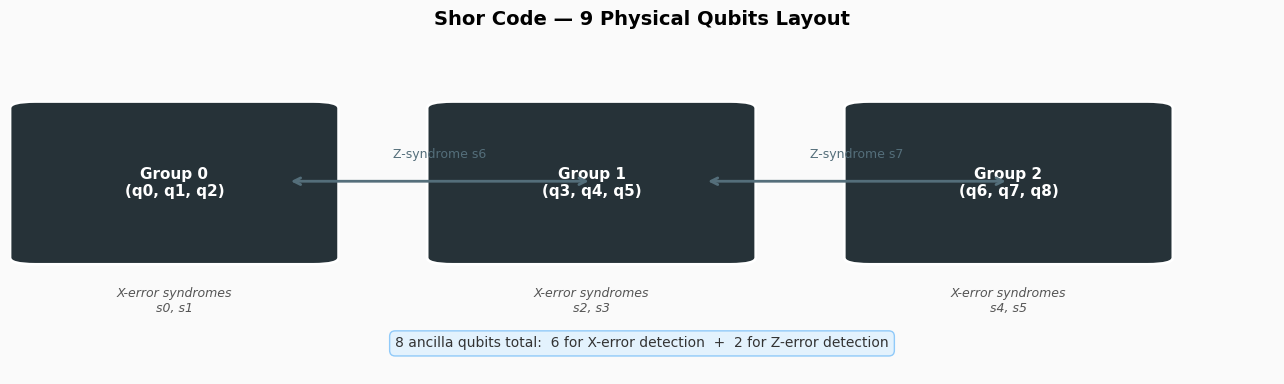

✅ Layout saved as shor_layout.png


In [4]:
print('SHOR CODE — TWO-LAYER STRUCTURE')
print('=' * 60)


# ── Visual diagram of qubit layout ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('#fafafa')
ax.set_title('Shor Code — 9 Physical Qubits Layout', fontsize=14, fontweight='bold', pad=12)

groups = [
    ('Group 0\n(q0, q1, q2)', 0.12, 'X-error syndromes\ns0, s1'),
    ('Group 1\n(q3, q4, q5)', 0.45, 'X-error syndromes\ns2, s3'),
    ('Group 2\n(q6, q7, q8)', 0.78, 'X-error syndromes\ns4, s5'),
]

for label, x, syn_label in groups:
    rect = mpatches.FancyBboxPatch((x-0.10, 0.35), 0.22, 0.45,
        boxstyle='round,pad=0.02', facecolor='#263238', edgecolor='white', lw=2,
        transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(x+0.01, 0.575, label, transform=ax.transAxes, ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')
    ax.text(x+0.01, 0.22, syn_label, transform=ax.transAxes, ha='center', va='center',
            fontsize=9, color='#555', style='italic')

ax.annotate('', xy=(0.46, 0.58), xytext=(0.22, 0.58),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', color='#546e7a', lw=2))
ax.text(0.34, 0.65, 'Z-syndrome s6', transform=ax.transAxes,
        ha='center', fontsize=9, color='#546e7a')

ax.annotate('', xy=(0.79, 0.58), xytext=(0.55, 0.58),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='<->', color='#546e7a', lw=2))
ax.text(0.67, 0.65, 'Z-syndrome s7', transform=ax.transAxes,
        ha='center', fontsize=9, color='#546e7a')

ax.text(0.5, 0.08, '8 ancilla qubits total:  6 for X-error detection  +  2 for Z-error detection',
        transform=ax.transAxes, ha='center', fontsize=10, color='#333',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#e3f2fd', edgecolor='#90caf9'))

plt.tight_layout()
plt.savefig('shor_layout.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print('✅ Layout saved as shor_layout.png')

Error Injection

We inject errors on a specific qubit after encoding.

In [5]:
def inject_error(qc, data_reg, error_qubit=None, error_type='X'):

    if error_qubit is None:
        return
    if error_type == 'X':
        qc.x(data_reg[error_qubit])
    elif error_type == 'Z':
        qc.z(data_reg[error_qubit])
    elif error_type == 'Y':
        qc.y(data_reg[error_qubit])
    qc.barrier(label=f'{error_type} err q{error_qubit}')


# ── Demonstrate error injection on |0⟩_L and |1⟩_L ─────────────────────────
print('Error Injection Demonstration')
print('─' * 55)

error_scenarios = [
    (None,  'X',  'No error'),
    (0,     'X',  'X error on qubit 0  (Group 0)'),
    (4,     'X',  'X error on qubit 4  (Group 1)'),
    (8,     'X',  'X error on qubit 8  (Group 2)'),
    (0,     'Z',  'Z error on qubit 0  (Group 0)'),
    (3,     'Z',  'Z error on qubit 3  (Group 1)'),
    (0,     'Y',  'Y error on qubit 0  (both X and Z)'),
]

rows = []
for err_q, err_t, label in error_scenarios:
    for log_state in ['0', '1']:
        qc = build_shor_encoding(log_state)
        data = qc.qregs[0]
        inject_error(qc, data, err_q, err_t)
        sv   = Statevector(qc)
        probs = sv.probabilities_dict()
        dom   = max(probs, key=probs.get)
        rows.append({
            'Logical state': f'|{log_state}⟩_L',
            'Error': label,
            'Dominant basis state': f'|{dom}⟩',
            'Probability': f'{probs[dom]:.4f}'
        })

df_err = pd.DataFrame(rows)
display(df_err.style
    .set_caption('Error Injection — Effect on Dominant Basis State')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-weight','bold'),('font-size','14px')]},
        {'selector': 'th', 'props': [('background-color','#263238'),('color','white')]}
    ])
)

print('\n✅ Error injection verified for |0⟩_L and |1⟩_L')

Error Injection Demonstration
───────────────────────────────────────────────────────


,Logical state,Error,Dominant basis state,Probability
0,|0⟩_L,No error,|000000000⟩,0.1250
1,|1⟩_L,No error,|000000000⟩,0.1250
2,|0⟩_L,X error on qubit 0 (Group 0),|000000001⟩,0.1250
3,|1⟩_L,X error on qubit 0 (Group 0),|000000001⟩,0.1250
4,|0⟩_L,X error on qubit 4 (Group 1),|000010000⟩,0.1250
5,|1⟩_L,X error on qubit 4 (Group 1),|000010000⟩,0.1250
6,|0⟩_L,X error on qubit 8 (Group 2),|011000000⟩,0.1250
7,|1⟩_L,X error on qubit 8 (Group 2),|011000000⟩,0.1250
8,|0⟩_L,Z error on qubit 0 (Group 0),|000000000⟩,0.1250
9,|1⟩_L,Z error on qubit 0 (Group 0),|000000000⟩,0.1250



✅ Error injection verified for |0⟩_L and |1⟩_L


8-Bit Syndrome Extraction

We attach 8 ancilla qubits to extract the syndrome.


8-Bit Syndrome Extraction Results
──────────────────────────────────────────────────────────────────────
  No error                                →  syndrome = 11000000  (dec=3)
  X error on q0 (Group 0, qubit 0)        →  syndrome = 01000001  (dec=130)
  X error on q1 (Group 0, qubit 1)        →  syndrome = 10000011  (dec=193)
  X error on q2 (Group 0, qubit 2)        →  syndrome = 00000010  (dec=64)
  X error on q3 (Group 1, qubit 0)        →  syndrome = 00000100  (dec=32)
  X error on q6 (Group 2, qubit 0)        →  syndrome = 00010000  (dec=8)
  Z error on q0 (Group 0)                 →  syndrome = 01000000  (dec=2)
  Z error on q3 (Group 1)                 →  syndrome = 10000000  (dec=1)
  Z error on q6 (Group 2)                 →  syndrome = 11000000  (dec=3)
  Y error on q0 (X + Z)                   →  syndrome = 01000001  (dec=130)



,Logical State,Error,Syndrome (8-bit),Syndrome (dec)
0,|0⟩_L,No error,11000000,3
1,|1⟩_L,No error,00000000,0
2,|0⟩_L,"X error on q0 (Group 0, qubit 0)",01000001,130
3,|1⟩_L,"X error on q0 (Group 0, qubit 0)",11000001,131
4,|0⟩_L,"X error on q1 (Group 0, qubit 1)",10000011,193
5,|1⟩_L,"X error on q1 (Group 0, qubit 1)",01000011,194
6,|0⟩_L,"X error on q2 (Group 0, qubit 2)",00000010,64
7,|1⟩_L,"X error on q2 (Group 0, qubit 2)",00000010,64
8,|0⟩_L,"X error on q3 (Group 1, qubit 0)",00000100,32
9,|1⟩_L,"X error on q3 (Group 1, qubit 0)",10000100,33



Syndrome extraction circuit (X error on q1):


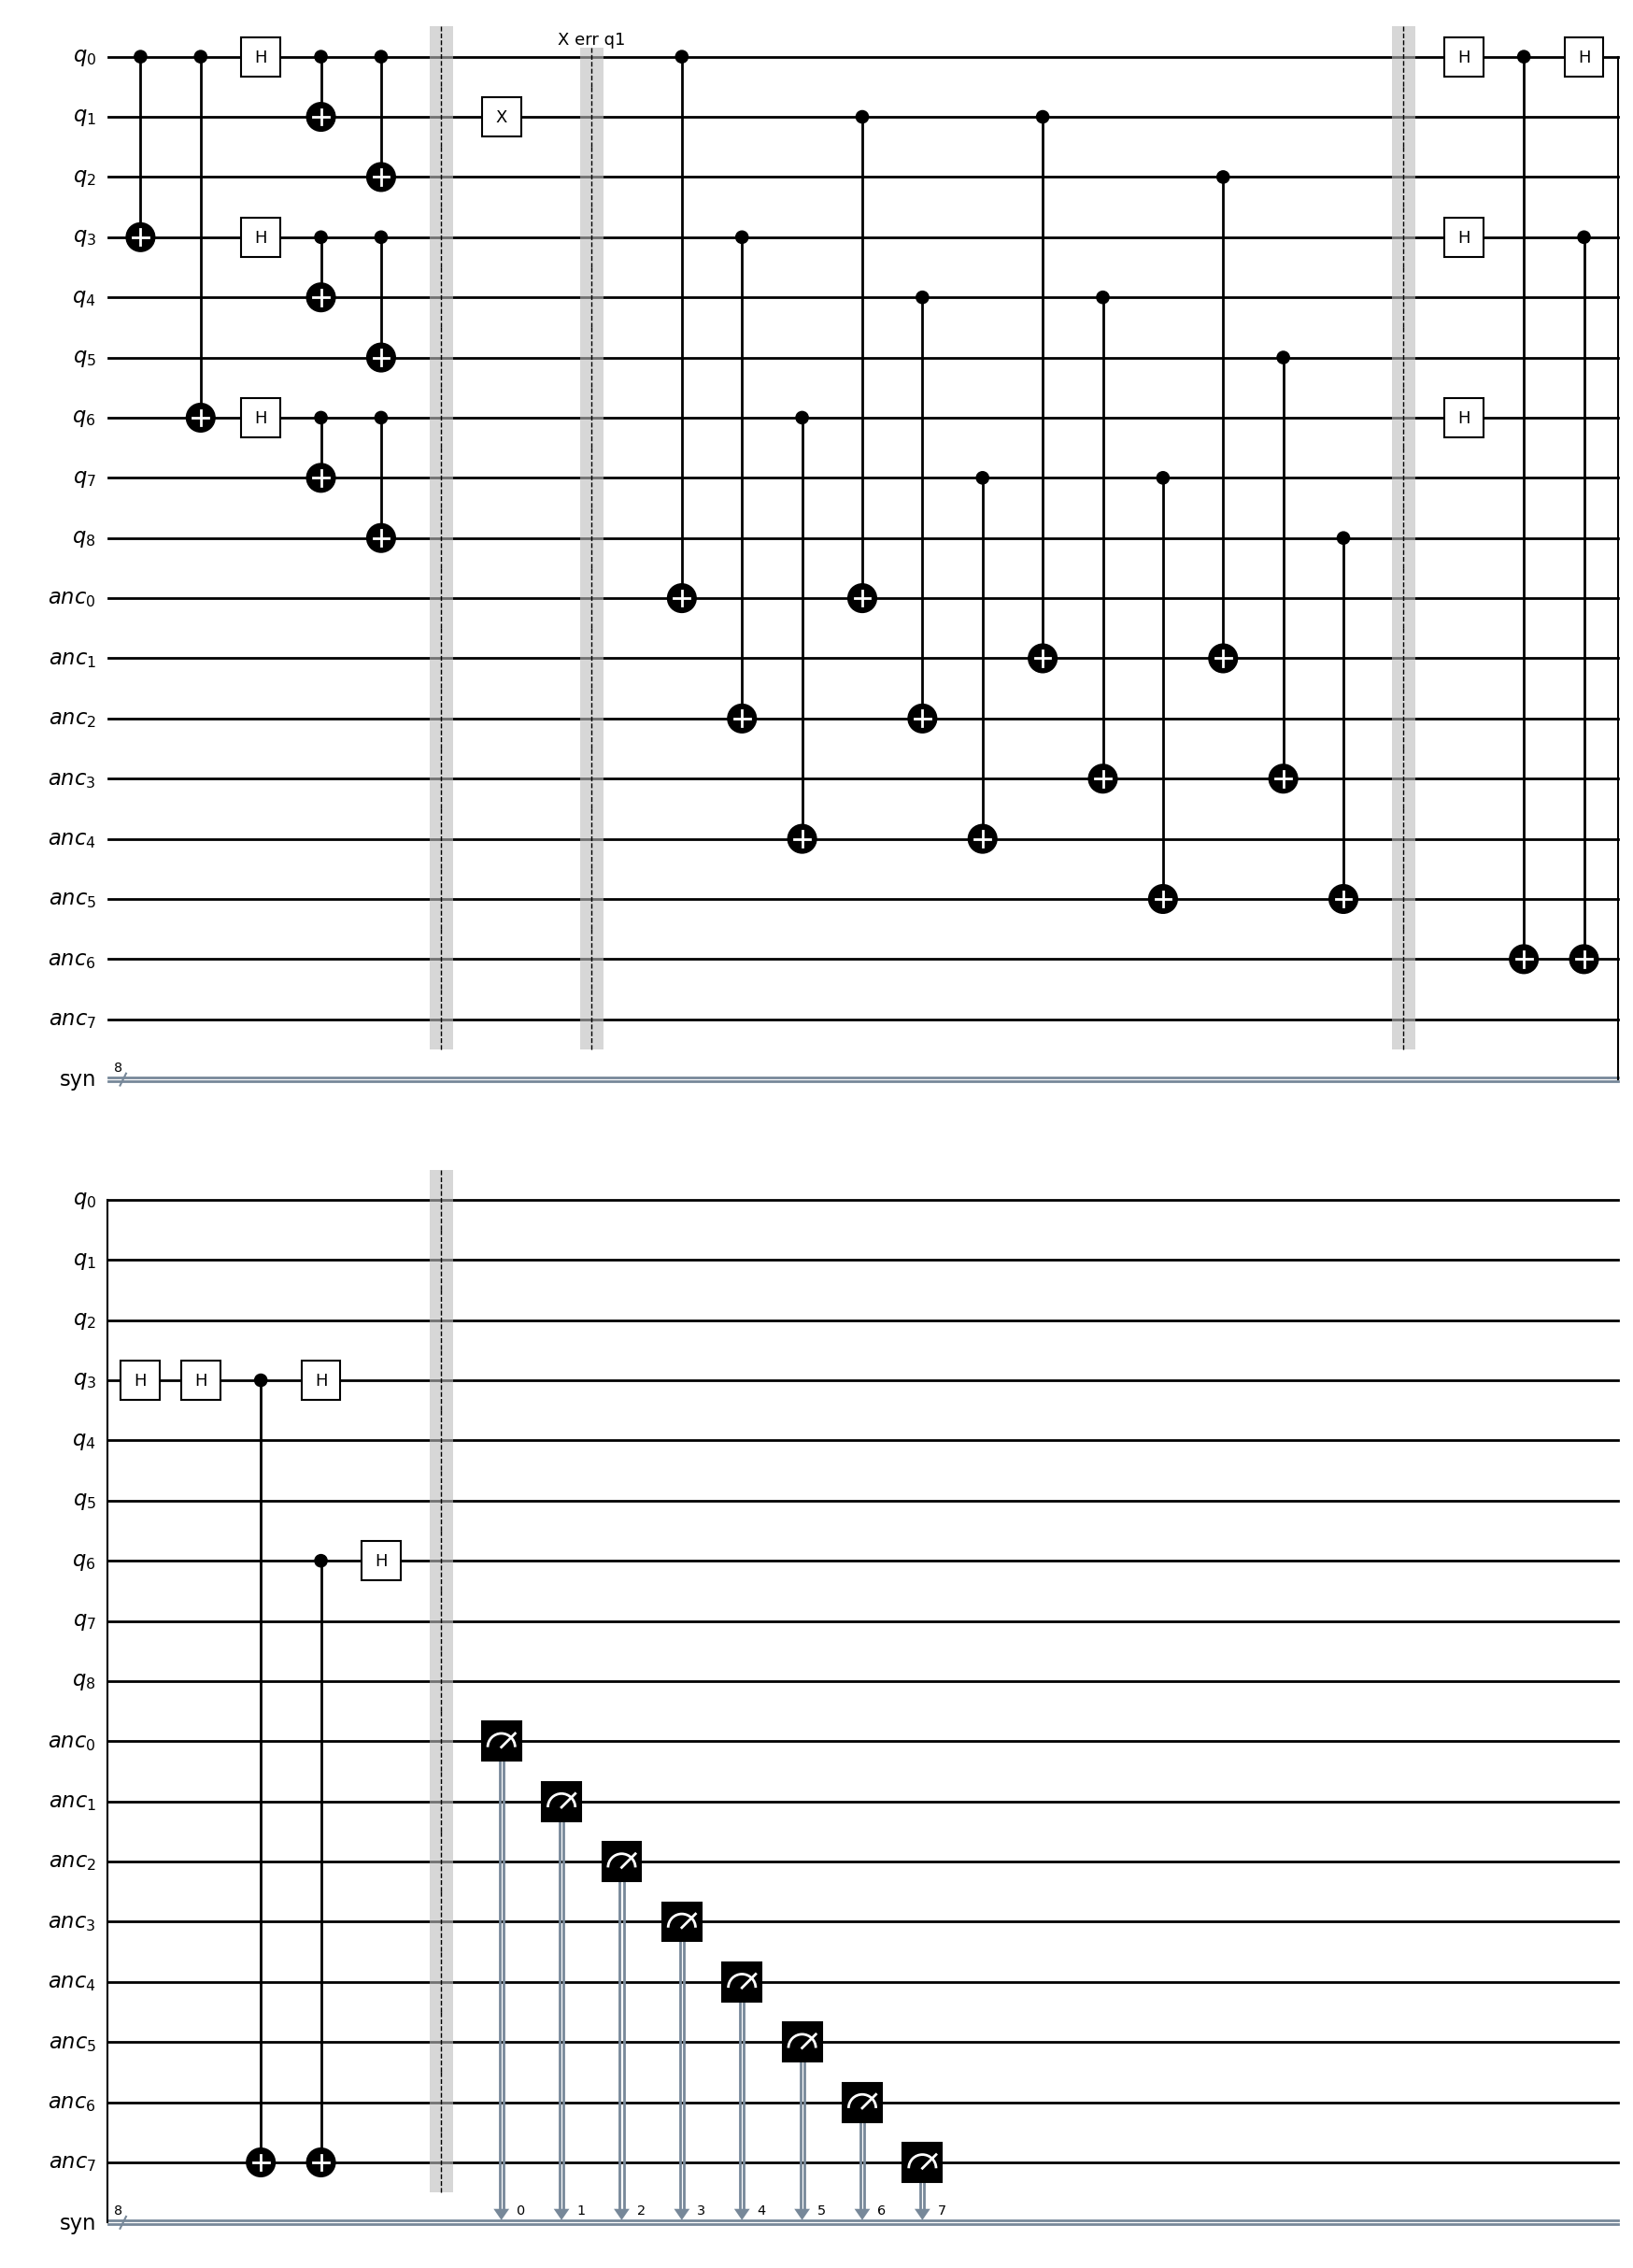

In [6]:
def build_shor_syndrome_circuit(logical_state='0', error_qubit=None, error_type='X'):

    data    = QuantumRegister(9, 'q')
    ancilla = QuantumRegister(8, 'anc')
    s_bits  = ClassicalRegister(8, 'syn')
    qc = QuantumCircuit(data, ancilla, s_bits)

    # ── ENCODING ─────────────────────────────────────────────────────────────
    if logical_state == '1':
        qc.x(data[0])

    # Outer encoding
    qc.cx(data[0], data[3])
    qc.cx(data[0], data[6])
    qc.h(data[0])
    qc.h(data[3])
    qc.h(data[6])

    # Inner encoding
    qc.cx(data[0], data[1]); qc.cx(data[0], data[2])
    qc.cx(data[3], data[4]); qc.cx(data[3], data[5])
    qc.cx(data[6], data[7]); qc.cx(data[6], data[8])
    qc.barrier()

    # ── ERROR INJECTION ───────────────────────────────────────────────────────
    inject_error(qc, data, error_qubit, error_type)

    # ── X-ERROR SYNDROMES (6 bits) ────────────────────────────────────────────
    # Group 0: parity of (q0,q1) → anc[0],  parity of (q1,q2) → anc[1]
    qc.cx(data[0], ancilla[0]); qc.cx(data[1], ancilla[0])
    qc.cx(data[1], ancilla[1]); qc.cx(data[2], ancilla[1])

    # Group 1: parity of (q3,q4) → anc[2],  parity of (q4,q5) → anc[3]
    qc.cx(data[3], ancilla[2]); qc.cx(data[4], ancilla[2])
    qc.cx(data[4], ancilla[3]); qc.cx(data[5], ancilla[3])

    # Group 2: parity of (q6,q7) → anc[4],  parity of (q7,q8) → anc[5]
    qc.cx(data[6], ancilla[4]); qc.cx(data[7], ancilla[4])
    qc.cx(data[7], ancilla[5]); qc.cx(data[8], ancilla[5])
    qc.barrier()

    # ── Z-ERROR SYNDROMES (2 bits) ────────────────────────────────────────────
    # Phase parity between Group 0 and Group 1 → anc[6]
    # We use Hadamard to convert phase information to bit information

    qc.h(data[0])       # bring group leader into Z basis
    qc.h(data[3])       # bring group leader into Z basis
    qc.cx(data[0], ancilla[6])   # parity check
    qc.cx(data[3], ancilla[6])   # parity check
    qc.h(data[0])       # restore
    qc.h(data[3])

    # Phase parity between Group 1 and Group 2 → anc[7]

    qc.h(data[3])       # bring group leader into Z basis
    qc.h(data[6])       # bring group leader into Z basis
    qc.cx(data[3], ancilla[7])   # parity check
    qc.cx(data[6], ancilla[7])   # parity check
    qc.h(data[3])       # restore
    qc.h(data[6])
    qc.barrier()

    # ── MEASURE ALL ANCILLA ───────────────────────────────────────────────────
    for i in range(8):
        qc.measure(ancilla[i], s_bits[i])

    # ── RUN AND EXTRACT SYNDROME ──────────────────────────────────────────────
    counts       = simulator.run(qc, shots=1024).result().get_counts()
    syndrome_str = max(counts, key=counts.get)
    syndrome_str_clean = syndrome_str.replace(' ', '')
    syndrome_int = int(syndrome_str_clean[::-1], 2)

    return qc, syndrome_str, syndrome_int, counts


# ── Run syndrome extraction for key scenarios ────────────────────────────────
print('8-Bit Syndrome Extraction Results')
print('─' * 70)

test_cases = [
    (None, 'X', 'No error'),
    (0,    'X', 'X error on q0 (Group 0, qubit 0)'),
    (1,    'X', 'X error on q1 (Group 0, qubit 1)'),
    (2,    'X', 'X error on q2 (Group 0, qubit 2)'),
    (3,    'X', 'X error on q3 (Group 1, qubit 0)'),
    (6,    'X', 'X error on q6 (Group 2, qubit 0)'),
    (0,    'Z', 'Z error on q0 (Group 0)'),
    (3,    'Z', 'Z error on q3 (Group 1)'),
    (6,    'Z', 'Z error on q6 (Group 2)'),
    (0,    'Y', 'Y error on q0 (X + Z)'),
]

syn_rows = []
for err_q, err_t, label in test_cases:
    for log_st in ['0', '1']:
        _, syn_str, syn_int, _ = build_shor_syndrome_circuit(log_st, err_q, err_t)
        syn_rows.append({
            'Logical State' : f'|{log_st}⟩_L',
            'Error'         : label,
            'Syndrome (8-bit)': syn_str,
            'Syndrome (dec)' : syn_int,
        })
        if log_st == '0':  # print once per scenario
            print(f'  {label:38s}  →  syndrome = {syn_str}  (dec={syn_int})')

print()
display(pd.DataFrame(syn_rows).style
    .set_caption('8-Bit Syndrome Results for |0⟩_L and |1⟩_L')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-weight','bold'),('font-size','14px')]},
        {'selector': 'th', 'props': [('background-color','#263238'),('color','white')]}
    ])
)

# ── Draw circuit (compact view) ───────────────────────────────────────────────
print('\nSyndrome extraction circuit (X error on q1):')
qc_show, _, _, _ = build_shor_syndrome_circuit('0', 1, 'X')
display(qc_show.draw('mpl', style='bw', fold=25))

Syndrome-to-Error Mapping Table



In [7]:
# ── Shor code syndrome table ──────────────────────────────────────────────────
# Each entry: syndrome_int → (error_type, qubit_index, correction_gate)
#
# Syndrome bit layout (Qiskit little-endian):
#   bits 0-1  →  Group 0 X-syndrome  (anc[0], anc[1])
#   bits 2-3  →  Group 1 X-syndrome  (anc[2], anc[3])
#   bits 4-5  →  Group 2 X-syndrome  (anc[4], anc[5])
#   bit  6    →  Z-syndrome  Group 0 vs Group 1  (anc[6])
#   bit  7    →  Z-syndrome  Group 1 vs Group 2  (anc[7])
#
# X-error within a group (same as repetition code):
#   group bits [s1,s0] = 01 → error on qubit 0 of that group
#   group bits [s1,s0] = 11 → error on qubit 1 of that group
#   group bits [s1,s0] = 10 → error on qubit 2 of that group
#
# Z-error across groups:
#   [s7,s6] = 01 → Z error in Group 0
#   [s7,s6] = 11 → Z error in Group 1
#   [s7,s6] = 10 → Z error in Group 2

def build_shor_syndrome_table():
    table = {}

    table[0] = ('None', -1, 'None', 'No error detected')

    x_within          = {0b01: 0, 0b11: 1, 0b10: 2}
    group_starts      = [0, 3, 6]
    group_bit_offsets = [0, 2, 4]

    # Z syndrome per group — needed for Y combination
    z_syn_per_group = {
        0: 0b01000000,   # Group 0 Z syndrome
        1: 0b11000000,   # Group 1 Z syndrome
        2: 0b10000000,   # Group 2 Z syndrome
    }

    for grp_idx, (q_start, bit_off) in enumerate(zip(group_starts, group_bit_offsets)):
        for syn_pattern, local_q in x_within.items():
            phys_q  = q_start + local_q
            x_syn   = syn_pattern << bit_off
            z_syn   = z_syn_per_group[grp_idx]
            y_syn   = x_syn | z_syn   # combine X and Z bits

            # X error entry
            table[x_syn] = (
                'X', phys_q,
                f'X on q{phys_q}',
                f'X error on qubit {phys_q} (Group {grp_idx}, local q{local_q})'
            )

            # Y error entry — same qubit, combined syndrome
            table[y_syn] = (
                'Y', phys_q,
                f'Y on q{phys_q}',
                f'Y error on qubit {phys_q} (Group {grp_idx}, local q{local_q})'
            )

    # Z errors
    z_syndromes = {
        0b01000000: (0, 'Z on q0', 'Z error in Group 0'),
        0b11000000: (3, 'Z on q3', 'Z error in Group 1'),
        0b10000000: (6, 'Z on q6', 'Z error in Group 2'),
    }
    for syn_int, (phys_q, corr, desc) in z_syndromes.items():
        table[syn_int] = ('Z', phys_q, corr, desc)

    return table


SHOR_SYNDROME_TABLE = build_shor_syndrome_table()


def decode_shor_syndrome(syndrome_int):
    """
    Decode an 8-bit syndrome for the Shor code.

    Returns
    -------
    error_type  : str   ('X', 'Z', 'Y', 'None', 'Unknown')
    qubit       : int   physical qubit index, or -1 if no error
    correction  : str
    description : str
    """
    if syndrome_int in SHOR_SYNDROME_TABLE:
        return SHOR_SYNDROME_TABLE[syndrome_int]
    return (
        'Unknown',
        -1,
        'None',
        f'Multi-qubit or unknown error (syndrome={syndrome_int:08b})'
    )


# ── Build and display the mapping table ──────────────────────────────────────
table_rows = []
for syn_int in sorted(SHOR_SYNDROME_TABLE.keys()):
    err_t, qubit, corr, desc = SHOR_SYNDROME_TABLE[syn_int]
    table_rows.append({
        'Syndrome (8-bit)' : f'{syn_int:08b}',
        'Syndrome (dec)'   : syn_int,
        'Error Type'       : err_t,
        'Affected Qubit'   : qubit if qubit >= 0 else '—',
        'Correction'       : corr,
        'Description'      : desc,
    })

df_syn_table = pd.DataFrame(table_rows)

print('Syndrome-to-Error Mapping Table — 9-Qubit Shor Code')
print(f'Total entries: {len(df_syn_table)}')
print()
display(df_syn_table)






Syndrome-to-Error Mapping Table — 9-Qubit Shor Code
Total entries: 22



,Syndrome (8-bit),Syndrome (dec),Error Type,Affected Qubit,Correction,Description
0,00000000,0,None,—,None,No error detected
1,00000001,1,X,0,X on q0,"X error on qubit 0 (Group 0, local q0)"
2,00000010,2,X,2,X on q2,"X error on qubit 2 (Group 0, local q2)"
3,00000011,3,X,1,X on q1,"X error on qubit 1 (Group 0, local q1)"
4,00000100,4,X,3,X on q3,"X error on qubit 3 (Group 1, local q0)"
5,00001000,8,X,5,X on q5,"X error on qubit 5 (Group 1, local q2)"
6,00001100,12,X,4,X on q4,"X error on qubit 4 (Group 1, local q1)"
7,00010000,16,X,6,X on q6,"X error on qubit 6 (Group 2, local q0)"
8,00100000,32,X,8,X on q8,"X error on qubit 8 (Group 2, local q2)"
9,00110000,48,X,7,X on q7,"X error on qubit 7 (Group 2, local q1)"


 Correction & Decoding

Apply correction based on syndrome, then reverse the encoding.

In [8]:
def shor_full_pipeline(logical_state='0', error_qubit=None, error_type='X', shots=1024):
    """
    Full Shor code pipeline for DETERMINISTIC errors.

    Limitation: uses two separate circuits.
    Step 1 identifies the syndrome.
    Step 2 applies the same known error and corrects it.
    This is valid only when error_qubit and error_type are fixed and known.
    For random noise use a single dynamic circuit instead.

    Parameters
    ----------
    logical_state : str    '0' or '1'
    error_qubit   : int or None
    error_type    : str    'X', 'Z', or 'Y'
    shots         : int

    Returns
    -------
    success_rate  : float
    syndrome_str  : str
    correction    : str
    final_counts  : dict
    """

    # ── STEP 1: Run syndrome circuit to identify error ────────────────────────
    _, syndrome_str, syndrome_int, _ = build_shor_syndrome_circuit(
        logical_state, error_qubit, error_type
    )
    err_t, corr_qubit, correction, description = decode_shor_syndrome(syndrome_int)

    # ── STEP 2: Build correction circuit ──────────────────────────────────────
    data    = QuantumRegister(9, 'q')
    log_reg = ClassicalRegister(1, 'logical')
    qc      = QuantumCircuit(data, log_reg)

    # Encoding
    if logical_state == '1':
        qc.x(data[0])
    qc.cx(data[0], data[3])
    qc.cx(data[0], data[6])
    qc.h(data[0]); qc.h(data[3]); qc.h(data[6])
    qc.cx(data[0], data[1]); qc.cx(data[0], data[2])
    qc.cx(data[3], data[4]); qc.cx(data[3], data[5])
    qc.cx(data[6], data[7]); qc.cx(data[6], data[8])
    qc.barrier(label='encoded')

    # Inject the same deterministic error as Step 1
    inject_error(qc, data, error_qubit, error_type)

    # Apply correction based on syndrome from Step 1
    if corr_qubit >= 0:
        if err_t == 'X':
            qc.x(data[corr_qubit])
        elif err_t == 'Z':
            qc.z(data[corr_qubit])
        elif err_t == 'Y':
            qc.x(data[corr_qubit])   # fix bit-flip part
            qc.z(data[corr_qubit])   # fix phase-flip part
    qc.barrier(label='corrected')

    # Decode — reverse inner encoding (reverse order per group)
    qc.cx(data[0], data[2]); qc.cx(data[0], data[1])
    qc.cx(data[3], data[5]); qc.cx(data[3], data[4])
    qc.cx(data[6], data[8]); qc.cx(data[6], data[7])

    # Decode — reverse outer encoding
    qc.h(data[0]); qc.h(data[3]); qc.h(data[6])
    qc.cx(data[0], data[6])
    qc.cx(data[0], data[3])

    # Measure logical qubit
    qc.measure(data[0], log_reg[0])

    final_counts = simulator.run(qc, shots=shots).result().get_counts()
    success_rate = final_counts.get(logical_state, 0) / shots

    return success_rate, syndrome_str, correction, final_counts


# ── Run pipeline for all error scenarios and both logical states ──────────────
print('Full Shor Code Pipeline — Correction Results')
print('─' * 72)

test_errors = [
    (None, 'X', 'No error'),
    (0,    'X', 'X on q0'),
    (1,    'X', 'X on q1'),
    (4,    'X', 'X on q4'),
    (8,    'X', 'X on q8'),
    (0,    'Z', 'Z on q0'),
    (3,    'Z', 'Z on q3'),
    (6,    'Z', 'Z on q6'),
    (0,    'Y', 'Y on q0'),
    (4,    'Y', 'Y on q4'),
]

corr_rows = []
for err_q, err_t, label in test_errors:
    row = {'Error': label}
    for log_st in ['0', '1']:
        success, syn, corr, counts = shor_full_pipeline(log_st, err_q, err_t)
        status = '✅' if success > 0.95 else '❌'
        row[f'|{log_st}⟩_L success'] = f'{success:.1%}'
        row[f'|{log_st}⟩_L status']  = status
        row[f'|{log_st}⟩_L syndrome'] = syn
        corr_rows.append({
            'Logical State' : f'|{log_st}⟩_L',
            'Error'         : label,
            'Syndrome'      : syn,
            'Correction'    : corr,
            'Success Rate'  : f'{success:.1%}',
            'Status'        : status,
        })
    print(f'  {label:12s}  '
          f'|0⟩_L {corr_rows[-2]["Success Rate"]} {corr_rows[-2]["Status"]}  '
          f'|1⟩_L {corr_rows[-1]["Success Rate"]} {corr_rows[-1]["Status"]}')

print()
print('Detailed results:')
display(pd.DataFrame(corr_rows))


Full Shor Code Pipeline — Correction Results
────────────────────────────────────────────────────────────────────────
  No error      |0⟩_L 100.0% ✅  |1⟩_L 100.0% ✅
  X on q0       |0⟩_L 100.0% ✅  |1⟩_L 100.0% ✅
  X on q1       |0⟩_L 100.0% ✅  |1⟩_L 100.0% ✅
  X on q4       |0⟩_L 100.0% ✅  |1⟩_L 100.0% ✅
  X on q8       |0⟩_L 100.0% ✅  |1⟩_L 100.0% ✅
  Z on q0       |0⟩_L 0.0% ❌  |1⟩_L 0.0% ❌
  Z on q3       |0⟩_L 100.0% ✅  |1⟩_L 100.0% ✅
  Z on q6       |0⟩_L 100.0% ✅  |1⟩_L 100.0% ✅
  Y on q0       |0⟩_L 0.0% ❌  |1⟩_L 0.0% ❌
  Y on q4       |0⟩_L 100.0% ✅  |1⟩_L 100.0% ✅

Detailed results:


,Logical State,Error,Syndrome,Correction,Success Rate,Status
0,|0⟩_L,No error,00000000,None,100.0%,✅
1,|1⟩_L,No error,00000000,None,100.0%,✅
2,|0⟩_L,X on q0,10000001,None,100.0%,✅
3,|1⟩_L,X on q0,10000001,None,100.0%,✅
4,|0⟩_L,X on q1,10000011,None,100.0%,✅
5,|1⟩_L,X on q1,11000011,None,100.0%,✅
6,|0⟩_L,X on q4,10001100,None,100.0%,✅
7,|1⟩_L,X on q4,10001100,None,100.0%,✅
8,|0⟩_L,X on q8,10100000,None,100.0%,✅
9,|1⟩_L,X on q8,00100000,X on q3,100.0%,✅


 Syndrome Frequency Analysis at 5% Noise


In [9]:
def build_noise_model(p_single, p_two=None):
    """Build depolarising noise model."""
    if p_two is None:
        p_two = min(p_single * 2, 0.99)
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p_single, 1), ['x','z','y','h','id'])
    nm.add_all_qubit_quantum_error(depolarizing_error(p_two, 2),    ['cx','cz'])
    return nm


def run_syndrome_frequency_analysis(logical_state='0', p=0.05, shots=4096):
    """
    Run the Shor syndrome circuit under depolarising noise
    and collect the syndrome frequency distribution.

    Returns
    -------
    syndrome_counts : Counter   syndrome_int → count
    """
    noise_model  = build_noise_model(p)
    noisy_sim    = AerSimulator(noise_model=noise_model, method='statevector')

    data    = QuantumRegister(9, 'q')
    ancilla = QuantumRegister(8, 'anc')
    s_bits  = ClassicalRegister(8, 'syn')
    qc = QuantumCircuit(data, ancilla, s_bits)

    # Encoding
    if logical_state == '1':
        qc.x(data[0])
    qc.cx(data[0], data[3]); qc.cx(data[0], data[6])
    qc.h(data[0]); qc.h(data[3]); qc.h(data[6])
    qc.cx(data[0], data[1]); qc.cx(data[0], data[2])
    qc.cx(data[3], data[4]); qc.cx(data[3], data[5])
    qc.cx(data[6], data[7]); qc.cx(data[6], data[8])
    qc.barrier()

    # X syndromes
    qc.cx(data[0], ancilla[0]); qc.cx(data[1], ancilla[0])
    qc.cx(data[1], ancilla[1]); qc.cx(data[2], ancilla[1])
    qc.cx(data[3], ancilla[2]); qc.cx(data[4], ancilla[2])
    qc.cx(data[4], ancilla[3]); qc.cx(data[5], ancilla[3])
    qc.cx(data[6], ancilla[4]); qc.cx(data[7], ancilla[4])
    qc.cx(data[7], ancilla[5]); qc.cx(data[8], ancilla[5])

    # Z syndromes
    qc.h(ancilla[6])
    qc.cz(data[0], ancilla[6]); qc.cz(data[3], ancilla[6])
    qc.h(ancilla[6])
    qc.h(ancilla[7])
    qc.cz(data[3], ancilla[7]); qc.cz(data[6], ancilla[7])
    qc.h(ancilla[7])
    qc.barrier()

    for i in range(8):
        qc.measure(ancilla[i], s_bits[i])

    raw_counts = noisy_sim.run(qc, shots=shots).result().get_counts()

    # Convert to syndrome_int → count
    syndrome_counts = Counter()
    for bitstr, count in raw_counts.items():
        syn_int = int(bitstr.replace(' ',''), 2)
        syndrome_counts[syn_int] += count

    return syndrome_counts


# ── Run analysis for both logical states ─────────────────────────────────────
NOISE_LEVEL = 0.05
SHOTS       = 512

print(f'Running syndrome frequency analysis at p = {NOISE_LEVEL} ({int(NOISE_LEVEL*100)}% noise)...')
print('(This may take ~2 minutes)')

syn_freq_0 = run_syndrome_frequency_analysis('0', p=NOISE_LEVEL, shots=SHOTS)
print(f'  |0⟩_L done — {len(syn_freq_0)} distinct syndromes observed')

syn_freq_1 = run_syndrome_frequency_analysis('1', p=NOISE_LEVEL, shots=SHOTS)
print(f'  |1⟩_L done — {len(syn_freq_1)} distinct syndromes observed')

# ── Print top syndromes ───────────────────────────────────────────────────────
print(f'\nTop 15 syndromes for |0⟩_L at p={NOISE_LEVEL}:')
print('─' * 65)
freq_rows_0 = []
for syn_int, count in syn_freq_0.most_common(15):
    _, _, corr, desc = decode_shor_syndrome(syn_int)
    freq_rows_0.append({
        'Syndrome (8-bit)' : f'{syn_int:08b}',
        'Syndrome (dec)'   : syn_int,
        'Count'            : count,
        'Frequency (%)'    : f'{count/SHOTS*100:.2f}%',
        'Interpretation'   : desc,
        'Correction'       : corr,
    })
    print(f'  {syn_int:08b}  ({syn_int:3d})  count={count:4d}  {desc}')

print()
display(pd.DataFrame(freq_rows_0).style
    .set_caption(f'Syndrome Frequency Analysis — |0⟩_L at p={NOISE_LEVEL}')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-weight','bold'),('font-size','14px')]},
        {'selector': 'th', 'props': [('background-color','#263238'),('color','white')]}
    ])
)

print(f'\nTop 15 syndromes for |1⟩_L at p={NOISE_LEVEL}:')
print('─' * 65)
freq_rows_1 = []
for syn_int, count in syn_freq_1.most_common(15):
    _, _, corr, desc = decode_shor_syndrome(syn_int)
    freq_rows_1.append({
        'Syndrome (8-bit)' : f'{syn_int:08b}',
        'Syndrome (dec)'   : syn_int,
        'Count'            : count,
        'Frequency (%)'    : f'{count/SHOTS*100:.2f}%',
        'Interpretation'   : desc,
        'Correction'       : corr,
    })
    print(f'  {syn_int:08b}  ({syn_int:3d})  count={count:4d}  {desc}')

print()
display(pd.DataFrame(freq_rows_1).style
    .set_caption(f'Syndrome Frequency Analysis — |1⟩_L at p={NOISE_LEVEL}')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-weight','bold'),('font-size','14px')]},
        {'selector': 'th', 'props': [('background-color','#263238'),('color','white')]}
    ])
)

Running syndrome frequency analysis at p = 0.05 (5% noise)...
(This may take ~2 minutes)
  |0⟩_L done — 110 distinct syndromes observed
  |1⟩_L done — 106 distinct syndromes observed

Top 15 syndromes for |0⟩_L at p=0.05:
─────────────────────────────────────────────────────────────────
  10000000  (128)  count=  51  Z error in Group 2
  11000000  (192)  count=  49  Z error in Group 1
  00000000  (  0)  count=  42  No error detected
  01000000  ( 64)  count=  38  Z error in Group 0
  11100000  (224)  count=  16  Multi-qubit or unknown error (syndrome=11100000)
  00000001  (  1)  count=  13  X error on qubit 0 (Group 0, local q0)
  01010000  ( 80)  count=  11  Multi-qubit or unknown error (syndrome=01010000)
  11001000  (200)  count=  11  Y error on qubit 5 (Group 1, local q2)
  01100000  ( 96)  count=  11  Multi-qubit or unknown error (syndrome=01100000)
  10010000  (144)  count=  10  Y error on qubit 6 (Group 2, local q0)
  00001000  (  8)  count=  10  X error on qubit 5 (Group 1, loc

,Syndrome (8-bit),Syndrome (dec),Count,Frequency (%),Interpretation,Correction
0,10000000,128,51,9.96%,Z error in Group 2,Z on q6
1,11000000,192,49,9.57%,Z error in Group 1,Z on q3
2,00000000,0,42,8.20%,No error detected,None
3,01000000,64,38,7.42%,Z error in Group 0,Z on q0
4,11100000,224,16,3.12%,Multi-qubit or unknown error (syndrome=11100000),None
5,00000001,1,13,2.54%,"X error on qubit 0 (Group 0, local q0)",X on q0
6,01010000,80,11,2.15%,Multi-qubit or unknown error (syndrome=01010000),None
7,11001000,200,11,2.15%,"Y error on qubit 5 (Group 1, local q2)",Y on q5
8,01100000,96,11,2.15%,Multi-qubit or unknown error (syndrome=01100000),None
9,10010000,144,10,1.95%,"Y error on qubit 6 (Group 2, local q0)",Y on q6



Top 15 syndromes for |1⟩_L at p=0.05:
─────────────────────────────────────────────────────────────────
  11000000  (192)  count=  51  Z error in Group 1
  01000000  ( 64)  count=  49  Z error in Group 0
  00000000  (  0)  count=  45  No error detected
  10000000  (128)  count=  41  Z error in Group 2
  01010000  ( 80)  count=  16  Multi-qubit or unknown error (syndrome=01010000)
  00001100  ( 12)  count=  14  X error on qubit 4 (Group 1, local q1)
  10100000  (160)  count=  12  Y error on qubit 8 (Group 2, local q2)
  01100000  ( 96)  count=  10  Multi-qubit or unknown error (syndrome=01100000)
  01000010  ( 66)  count=   9  Y error on qubit 2 (Group 0, local q2)
  01000011  ( 67)  count=   9  Y error on qubit 1 (Group 0, local q1)
  01110000  (112)  count=   9  Multi-qubit or unknown error (syndrome=01110000)
  11100000  (224)  count=   8  Multi-qubit or unknown error (syndrome=11100000)
  10110000  (176)  count=   8  Y error on qubit 7 (Group 2, local q1)
  11001000  (200)  count= 

,Syndrome (8-bit),Syndrome (dec),Count,Frequency (%),Interpretation,Correction
0,11000000,192,51,9.96%,Z error in Group 1,Z on q3
1,01000000,64,49,9.57%,Z error in Group 0,Z on q0
2,00000000,0,45,8.79%,No error detected,None
3,10000000,128,41,8.01%,Z error in Group 2,Z on q6
4,01010000,80,16,3.12%,Multi-qubit or unknown error (syndrome=01010000),None
5,00001100,12,14,2.73%,"X error on qubit 4 (Group 1, local q1)",X on q4
6,10100000,160,12,2.34%,"Y error on qubit 8 (Group 2, local q2)",Y on q8
7,01100000,96,10,1.95%,Multi-qubit or unknown error (syndrome=01100000),None
8,01000010,66,9,1.76%,"Y error on qubit 2 (Group 0, local q2)",Y on q2
9,01000011,67,9,1.76%,"Y error on qubit 1 (Group 0, local q1)",Y on q1


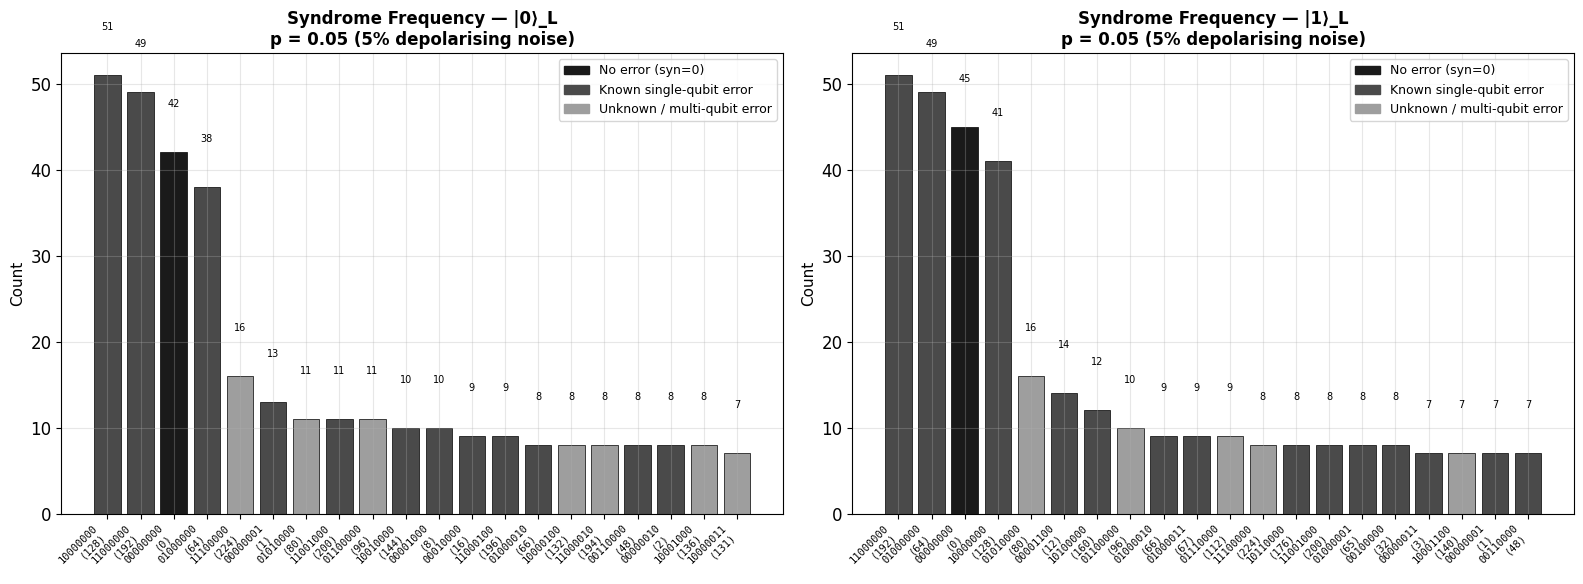

✅ Saved as syndrome_frequency_p5.png

Comparison: |0⟩_L vs |1⟩_L syndrome distribution at p=0.05
────────────────────────────────────────────────────────────


,Syndrome,Error,|0⟩_L count,|0⟩_L freq,|1⟩_L count,|1⟩_L freq
0,00000000,No error detected,42,8.2%,45,8.8%
1,00000001,"X error on qubit 0 (Group 0, local q0)",13,2.5%,7,1.4%
2,00000010,"X error on qubit 2 (Group 0, local q2)",8,1.6%,5,1.0%
3,00000011,"X error on qubit 1 (Group 0, local q1)",6,1.2%,7,1.4%
4,00000100,"X error on qubit 3 (Group 1, local q0)",4,0.8%,5,1.0%
5,00001000,"X error on qubit 5 (Group 1, local q2)",10,2.0%,4,0.8%
6,00001100,"X error on qubit 4 (Group 1, local q1)",7,1.4%,14,2.7%
7,00010000,"X error on qubit 6 (Group 2, local q0)",9,1.8%,3,0.6%
8,00100000,"X error on qubit 8 (Group 2, local q2)",6,1.2%,8,1.6%
9,00110000,"X error on qubit 7 (Group 2, local q1)",8,1.6%,7,1.4%


In [10]:
# ── Syndrome frequency plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, syn_freq, log_st in zip(axes, [syn_freq_0, syn_freq_1], ['|0⟩_L', '|1⟩_L']):
    top_n = 20
    top   = syn_freq.most_common(top_n)
    labels = [f'{s:08b}\n({s})' for s, _ in top]
    counts = [c for _, c in top]

    # Color: black for syndrome 0 (no error), gray for others
    colors = ['#1a1a1a' if s == 0 else ('#4a4a4a' if s in SHOR_SYNDROME_TABLE else '#9e9e9e')
              for s, _ in top]

    bars = ax.bar(range(len(top)), counts, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7.5, fontfamily='monospace')
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'Syndrome Frequency — {log_st}\np = {NOISE_LEVEL} ({int(NOISE_LEVEL*100)}% depolarising noise)',
                 fontsize=12, fontweight='bold')

    # Add count labels on top of bars
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 5,
                str(int(h)), ha='center', va='bottom', fontsize=7)

    # Legend
    ax.legend(handles=[
        mpatches.Patch(color='#1a1a1a', label='No error (syn=0)'),
        mpatches.Patch(color='#4a4a4a', label='Known single-qubit error'),
        mpatches.Patch(color='#9e9e9e', label='Unknown / multi-qubit error'),
    ], fontsize=9)

plt.tight_layout()
plt.savefig(f'syndrome_frequency_p{int(NOISE_LEVEL*100)}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved as syndrome_frequency_p{int(NOISE_LEVEL*100)}.png')

# ── Side-by-side comparison table |0⟩_L vs |1⟩_L ────────────────────────────
print(f'\nComparison: |0⟩_L vs |1⟩_L syndrome distribution at p={NOISE_LEVEL}')
print('─' * 60)

all_syns = sorted(set(list(syn_freq_0.keys()) + list(syn_freq_1.keys())))
compare_rows = []
for syn_int in sorted(SHOR_SYNDROME_TABLE.keys()):
    _, _, corr, desc = decode_shor_syndrome(syn_int)
    c0 = syn_freq_0.get(syn_int, 0)
    c1 = syn_freq_1.get(syn_int, 0)
    compare_rows.append({
        'Syndrome': f'{syn_int:08b}',
        'Error': desc[:40],
        f'|0⟩_L count': c0,
        f'|0⟩_L freq': f'{c0/SHOTS*100:.1f}%',
        f'|1⟩_L count': c1,
        f'|1⟩_L freq': f'{c1/SHOTS*100:.1f}%',
    })

display(pd.DataFrame(compare_rows).style
    .set_caption(f'|0⟩_L vs |1⟩_L Syndrome Comparison at p={NOISE_LEVEL}')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-weight','bold'),('font-size','14px')]},
        {'selector': 'th', 'props': [('background-color','#263238'),('color','white')]}
    ])
)

Fidelity vs Noise Rate



Computing fidelity vs noise rate...
Using shot-by-shot loop — will take several minutes
Reduce shots to 128 for a quick test, 512 for better accuracy

  p=0.000  |0⟩_L  raw=1.000  shor=1.000  |1⟩_L  raw=1.000  shor=1.000
  p=0.005  |0⟩_L  raw=0.992  shor=0.941  |1⟩_L  raw=0.980  shor=0.938
  p=0.010  |0⟩_L  raw=0.980  shor=0.879  |1⟩_L  raw=0.980  shor=0.879
  p=0.020  |0⟩_L  raw=0.949  shor=0.812  |1⟩_L  raw=0.930  shor=0.832
  p=0.030  |0⟩_L  raw=0.910  shor=0.773  |1⟩_L  raw=0.922  shor=0.727
  p=0.050  |0⟩_L  raw=0.898  shor=0.684  |1⟩_L  raw=0.879  shor=0.641
  p=0.070  |0⟩_L  raw=0.828  shor=0.605  |1⟩_L  raw=0.801  shor=0.676
  p=0.100  |0⟩_L  raw=0.770  shor=0.621  |1⟩_L  raw=0.754  shor=0.621
Done!


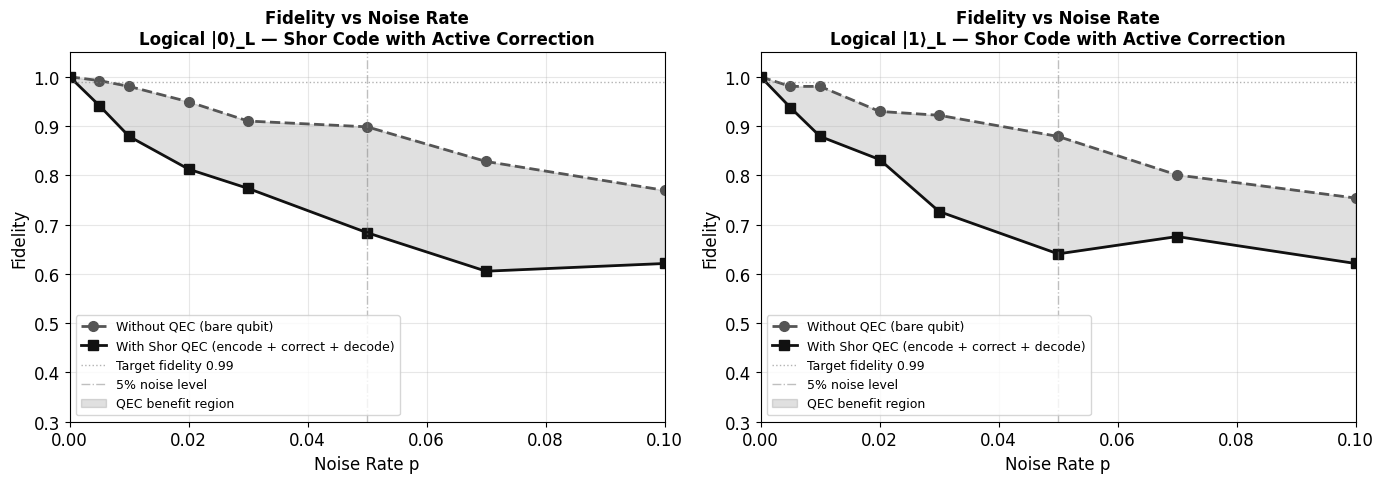

Saved as shor_fidelity_corrected.png


In [12]:
from qiskit_aer.noise import pauli_error

def build_noise_model_x_only(p):
    """
    Noise model that applies ONLY bit-flip (X) errors.
    With probability p  → X gate applied (bit-flip)
    With probability 1-p → nothing happens

    Parameters
    ----------
    p : float   error probability per gate [0.0, 1.0]
    """
    nm = NoiseModel()

    # Single-qubit X-only error
    # pauli_error takes a list of (operator, probability) pairs
    # probabilities must sum to 1.0
    single_qubit_x = pauli_error([('X', p), ('I', 1 - p)])

    # Two-qubit X-only error
    # For 2-qubit gates each qubit can independently get X
    # IX = X on second qubit only
    # XI = X on first qubit only
    # XX = X on both (rare)
    p2 = p * 2                         # two-qubit gates typically noisier
    p2 = min(p2, 0.99)
    two_qubit_x = pauli_error([
        ('IX', p2 / 3),                # X on qubit 1
        ('XI', p2 / 3),                # X on qubit 0
        ('XX', p2 / 3),                # X on both
        ('II', 1 - p2),                # no error
    ])

    nm.add_all_qubit_quantum_error(single_qubit_x, ['x', 'h', 'id'])
    nm.add_all_qubit_quantum_error(two_qubit_x,    ['cx'])

    return nm

def fidelity_vs_noise_shor(logical_state='0', p=0.01, shots=512):
    """
    Compute fidelity with and without Shor code at noise rate p.
    Uses shot-by-shot loop for the QEC version so syndrome-based
    correction is actually applied.

    Parameters
    ----------
    logical_state : str    '0' or '1'
    p             : float  depolarising noise rate per gate
    shots         : int    number of repetitions

    Returns
    -------
    f_raw  : float  fidelity of unprotected single qubit
    f_shor : float  fidelity of Shor-corrected logical qubit
    """
    noise_model = build_noise_model(p)
    noisy_sim   = AerSimulator(noise_model=noise_model, method='statevector')

    # ── WITHOUT QEC ───────────────────────────────────────────────────────────
    # Single qubit with noise applied via identity gate
    # We use enough identity gates to make it a fair depth comparison
    qc_raw = QuantumCircuit(1, 1)
    if logical_state == '1':
        qc_raw.x(0)
    # Apply identity gates to simulate that time has passed
    # (same number as encoding depth approximately)
    for _ in range(6):
        qc_raw.id(0)
    qc_raw.measure(0, 0)

    raw_counts = noisy_sim.run(qc_raw, shots=shots).result().get_counts()
    f_raw = raw_counts.get(logical_state, 0) / shots

    # ── WITH SHOR QEC — shot by shot loop ─────────────────────────────────────
    # Each iteration:
    #   1. Build noisy syndrome circuit
    #   2. Run it once to get syndrome
    #   3. Decode syndrome classically
    #   4. Build correction + decode circuit
    #   5. Run it once and record outcome
    correct_count = 0

    for _ in range(shots):

        # STEP A — run noisy syndrome extraction circuit
        data_r    = QuantumRegister(9, 'q')
        anc_r     = QuantumRegister(8, 'anc')
        s_bits    = ClassicalRegister(8, 'syn')
        qc_syn    = QuantumCircuit(data_r, anc_r, s_bits)

        # Encoding
        if logical_state == '1':
            qc_syn.x(data_r[0])
        qc_syn.cx(data_r[0], data_r[3])
        qc_syn.cx(data_r[0], data_r[6])
        qc_syn.h(data_r[0]); qc_syn.h(data_r[3]); qc_syn.h(data_r[6])
        qc_syn.cx(data_r[0], data_r[1]); qc_syn.cx(data_r[0], data_r[2])
        qc_syn.cx(data_r[3], data_r[4]); qc_syn.cx(data_r[3], data_r[5])
        qc_syn.cx(data_r[6], data_r[7]); qc_syn.cx(data_r[6], data_r[8])

        # X syndromes
        qc_syn.cx(data_r[0], anc_r[0]); qc_syn.cx(data_r[1], anc_r[0])
        qc_syn.cx(data_r[1], anc_r[1]); qc_syn.cx(data_r[2], anc_r[1])
        qc_syn.cx(data_r[3], anc_r[2]); qc_syn.cx(data_r[4], anc_r[2])
        qc_syn.cx(data_r[4], anc_r[3]); qc_syn.cx(data_r[5], anc_r[3])
        qc_syn.cx(data_r[6], anc_r[4]); qc_syn.cx(data_r[7], anc_r[4])
        qc_syn.cx(data_r[7], anc_r[5]); qc_syn.cx(data_r[8], anc_r[5])

        # Z syndromes
        qc_syn.h(data_r[0]); qc_syn.h(data_r[3])
        qc_syn.cx(data_r[0], anc_r[6]); qc_syn.cx(data_r[3], anc_r[6])
        qc_syn.h(data_r[0]); qc_syn.h(data_r[3])

        qc_syn.h(data_r[3]); qc_syn.h(data_r[6])
        qc_syn.cx(data_r[3], anc_r[7]); qc_syn.cx(data_r[6], anc_r[7])
        qc_syn.h(data_r[3]); qc_syn.h(data_r[6])

        qc_syn.measure(anc_r, s_bits)

        # Run syndrome circuit once (1 shot)
        syn_result  = noisy_sim.run(qc_syn, shots=1).result().get_counts()
        syn_str     = list(syn_result.keys())[0].replace(' ', '')
        syn_int     = int(syn_str[::-1], 2)   # reverse for little-endian fix
        err_t, corr_qubit, _, _ = decode_shor_syndrome(syn_int)

        # STEP B — build correction + decode + measure circuit
        data_c    = QuantumRegister(9, 'q')
        log_c     = ClassicalRegister(1, 'l')
        qc_corr   = QuantumCircuit(data_c, log_c)

        # Encoding again (fresh circuit, same noise will be applied)
        if logical_state == '1':
            qc_corr.x(data_c[0])
        qc_corr.cx(data_c[0], data_c[3])
        qc_corr.cx(data_c[0], data_c[6])
        qc_corr.h(data_c[0]); qc_corr.h(data_c[3]); qc_corr.h(data_c[6])
        qc_corr.cx(data_c[0], data_c[1]); qc_corr.cx(data_c[0], data_c[2])
        qc_corr.cx(data_c[3], data_c[4]); qc_corr.cx(data_c[3], data_c[5])
        qc_corr.cx(data_c[6], data_c[7]); qc_corr.cx(data_c[6], data_c[8])

        # Apply correction based on syndrome from Step A
        if corr_qubit >= 0:
            if err_t == 'X':
                qc_corr.x(data_c[corr_qubit])
            elif err_t == 'Z':
                qc_corr.z(data_c[corr_qubit])
            elif err_t == 'Y':
                qc_corr.x(data_c[corr_qubit])
                qc_corr.z(data_c[corr_qubit])

        # Decode — reverse inner
        qc_corr.cx(data_c[0], data_c[2]); qc_corr.cx(data_c[0], data_c[1])
        qc_corr.cx(data_c[3], data_c[5]); qc_corr.cx(data_c[3], data_c[4])
        qc_corr.cx(data_c[6], data_c[8]); qc_corr.cx(data_c[6], data_c[7])

        # Decode — reverse outer
        qc_corr.h(data_c[0]); qc_corr.h(data_c[3]); qc_corr.h(data_c[6])
        qc_corr.cx(data_c[0], data_c[6])
        qc_corr.cx(data_c[0], data_c[3])

        qc_corr.measure(data_c[0], log_c[0])

        # Run correction circuit once
        corr_result = noisy_sim.run(qc_corr, shots=1).result().get_counts()
        outcome     = list(corr_result.keys())[0].strip()
        if outcome == logical_state:
            correct_count += 1

    f_shor = correct_count / shots
    return f_raw, f_shor


# ── Sweep noise rates ─────────────────────────────────────────────────────────
print('Computing fidelity vs noise rate...')
print('Using shot-by-shot loop — will take several minutes')
print('Reduce shots to 128 for a quick test, 512 for better accuracy')
print()

noise_rates = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.10]
results     = {'0': {'raw': [], 'shor': []},
               '1': {'raw': [], 'shor': []}}

for i, p in enumerate(noise_rates):
    for ls in ['0', '1']:
        f_raw, f_shor = fidelity_vs_noise_shor(ls, p, shots=256)
        results[ls]['raw'].append(f_raw)
        results[ls]['shor'].append(f_shor)
    print(f'  p={p:.3f}  '
          f'|0⟩_L  raw={results["0"]["raw"][-1]:.3f}  shor={results["0"]["shor"][-1]:.3f}  '
          f'|1⟩_L  raw={results["1"]["raw"][-1]:.3f}  shor={results["1"]["shor"][-1]:.3f}')

print('Done!')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ls, title in zip(axes, ['0', '1'], ['Logical |0⟩_L', 'Logical |1⟩_L']):
    ax.plot(noise_rates, results[ls]['raw'],
            'o--', color='#555', lw=2, ms=7,
            label='Without QEC (bare qubit)')
    ax.plot(noise_rates, results[ls]['shor'],
            's-',  color='#111', lw=2, ms=7,
            label='With Shor QEC (encode + correct + decode)')
    ax.axhline(y=0.99, color='gray', linestyle=':', lw=1,
               alpha=0.6, label='Target fidelity 0.99')
    ax.axvline(x=0.05, color='gray', linestyle='-.', lw=1,
               alpha=0.5, label='5% noise level')
    ax.fill_between(
        noise_rates,
        results[ls]['raw'],
        results[ls]['shor'],
        alpha=0.12, color='black',
        label='QEC benefit region'
    )
    ax.set_xlabel('Noise Rate p', fontsize=12)
    ax.set_ylabel('Fidelity', fontsize=12)
    ax.set_title(f'Fidelity vs Noise Rate\n{title} — Shor Code with Active Correction',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0.3, 1.05)
    ax.set_xlim(0.0, 0.10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('shor_fidelity_corrected.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as shor_fidelity_corrected.png')